
## 🎯 Optimization Objectives

We will:

- Analyze the class imbalance
- Establish baseline performance
- Experiment with class-weighted models
- Evaluate SMOTE-based resampling
- Perform hyperparameter tuning
- Optimize the classification threshold
- Compare optimized models
- Select the final model for deployment

In [2]:
import pandas as pd
import numpy as np

# ==========================================================
# Machine Learning Models
# ==========================================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ==========================================================
# Model Selection & Optimization
# ==========================================================

from sklearn.model_selection import (
    StratifiedKFold,
    RandomizedSearchCV
)

# ==========================================================
# Evaluation Metrics
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve
)

# ==========================================================
# Imbalanced Learning
# ==========================================================

from imblearn.over_sampling import SMOTE

# ==========================================================
# Visualization
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================================
# Utilities
# ==========================================================

import warnings
import joblib
import os

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

### Load Processed Datasets

In [3]:
X_train  = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (204277, 24)
X_test : (51070, 24)
y_train: (204277,)
y_test : (51070,)


# Analyze Class Distribution
The training data contains significantly more non-default cases than
default cases.

This imbalance can cause a model to favor the majority class.

In [4]:
class_distribution = pd.DataFrame({
    "Count": y_train.value_counts(),
    "Percentage": y_train.value_counts(normalize=True) * 100
})

class_distribution

,Count,Percentage
Default,,
0,180555,88.387337
1,23722,11.612663


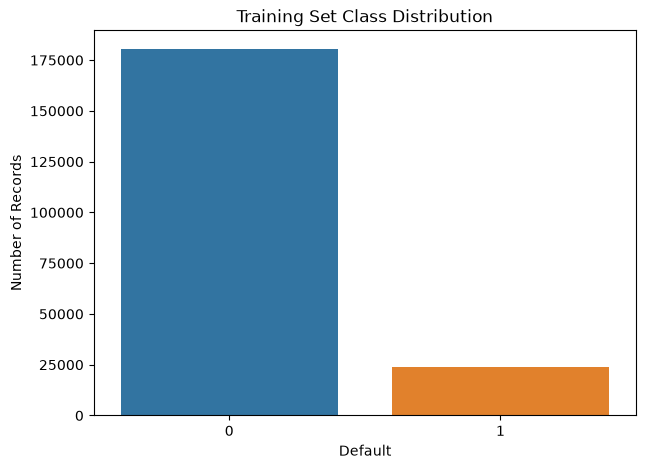

In [5]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x=y_train,
    hue=y_train,
    legend=False
)

plt.title("Training Set Class Distribution")
plt.xlabel("Default")
plt.ylabel("Number of Records")

plt.show()

## Outcome of this

The training dataset is imbalanced with "Default = 0" representing the majority class and "Default = 1" representing the minority class


In [6]:
baseline_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        0.8852,
        0.8014,
        0.8853,
        0.8865
    ],
    "Precision": [
        0.6024,
        0.1958,
        0.6437,
        0.5928
    ],
    "Recall": [
        0.0332,
        0.2285,
        0.0283,
        0.0727
    ],
    "F1 Score": [
        0.0630,
        0.2108,
        0.0543,
        0.1295
    ],
    "ROC-AUC": [
        0.7531,
        0.5526,
        0.7412,
        0.7544
    ]
})

baseline_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8852,0.6024,0.0332,0.0630,0.7531
1,Decision Tree,0.8014,0.1958,0.2285,0.2108,0.5526
2,Random Forest,0.8853,0.6437,0.0283,0.0543,0.7412
3,XGBoost,0.8865,0.5928,0.0727,0.1295,0.7544


# Class Weighted models

Instead of changing the dataset itself, class weighting changes the cost
associated with misclassifying different classes.

We will test class weighting on:

- Logistic Regression
- Decision Tree
- Random Forest

XGBoost will be handled separately using its `scale_pos_weight` parameter.



# Calculate Class Weight Ratio

For Binary classification, Imbalance ratio is estimated using : 
    Number of majority-class samples
    --------------------------------
    Number of minority-class samples

This value will provides an initial weihting strategy for XGboost


In [7]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Negative Class:", negative_count)
print("Positive Class:", positive_count)
print("Scale Positive Weight:", round(scale_pos_weight, 2))

Negative Class: 180555
Positive Class: 23722
Scale Positive Weight: 7.61


## Interpretation

The calculated ratio indicates how much more frequently the majority class
appears compared with the minority class.

This ratio will be used as an initial class-weighting strategy rather than
being treated as a guaranteed optimal value.

### Class-Weighted Decision Tree

With balanced class weights

In [8]:
weighted_dt = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)

weighted_dt.fit(X_train, y_train)

dt_pred = weighted_dt.predict(X_test)
dt_prob = weighted_dt.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall   :", recall_score(y_test, dt_pred))
print("F1 Score :", f1_score(y_test, dt_pred))
print("ROC-AUC  :", roc_auc_score(y_test, dt_prob))

Accuracy : 0.815273154493832
Precision: 0.20378826314899373
Recall   : 0.20316978587084808
F1 Score : 0.20347855454238434
ROC-AUC  : 0.5494348674585636


### Class-Weighted Random Forest
Trained with balanced class weights to increase the importance of minority-class observations.

In [9]:
weighted_rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

weighted_rf.fit(X_train, y_train)

rf_pred = weighted_rf.predict(X_test)
rf_prob = weighted_rf.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, rf_prob))

Accuracy : 0.880634423340513
Precision: 0.45709828393135726
Recall   : 0.14820435002529084
F1 Score : 0.2238349885408709
ROC-AUC  : 0.7472354460486652


### Class-weighted Logistic Regression

Trained with balanced class weights to increase the importance of minority-class observations.

In [10]:
weighted_lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

weighted_lr.fit(X_train, y_train)

lr_pred = weighted_lr.predict(X_test)
lr_prob = weighted_lr.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))
print("ROC-AUC  :", roc_auc_score(y_test, lr_prob))

Accuracy : 0.6763266105345604
Precision: 0.21955866010477854
Recall   : 0.6995447647951442
F1 Score : 0.3342194296761721
ROC-AUC  : 0.7531804240610736


### Class-Weighted XGBoost

XGBoost handles class imbalance using the `scale_pos_weight` parameter.

The calculated class ratio will be used as an initial value.

In [11]:
weighted_xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

weighted_xgb.fit(X_train, y_train)

xgb_pred = weighted_xgb.predict(X_test)
xgb_prob = weighted_xgb.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall   :", recall_score(y_test, xgb_pred))
print("F1 Score :", f1_score(y_test, xgb_pred))
print("ROC-AUC  :", roc_auc_score(y_test, xgb_prob))

Accuracy : 0.7128451145486587
Precision: 0.23446430743037822
Recall   : 0.6501433147867138
F1 Score : 0.34463958528846583
ROC-AUC  : 0.7528113921691796


In [12]:
# SUMMARY OF RESULTS

# XG boost : 
# Recall(Before) : 0.0727 --> 7.27%
# Recall(After)  : 0.6501 --> 65.01%

# That's a massive improvement in recall

## Create Validation Set

The original training data will be divided into :

- Training Set
- Validation Set → Used for model and threshold        optimization
- Test Set

(the test set will not be used during threshold selection of hyparameter optimization)



In [13]:
from sklearn.model_selection import train_test_split

X_model, X_validation, y_model, y_validation = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Model Training Features :", X_model.shape)
print("Validation Features     :", X_validation.shape)

print("Model Training Target   :", y_model.shape)
print("Validation Target       :", y_validation.shape)

Model Training Features : (163421, 24)
Validation Features     : (40856, 24)
Model Training Target   : (163421,)
Validation Target       : (40856,)


#### Before training , we verify that stratification preserved the proportion of default and non-default cases in validation set

In [14]:
validation_distribution = pd.DataFrame({
    "Count": y_validation.value_counts(),
    "Percentage": y_validation.value_counts(normalize=True) * 100
})

validation_distribution

,Count,Percentage
Default,,
0,36112,88.388486
1,4744,11.611514


### Retrain Class-Weighted XGboost
- We have to train the class weighted XGboost because previous we have trained using the entire training set

- For proper threshold optimization, we retrain the model using only the model-training subset.. 



In [15]:
weighted_xgb_validation = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

weighted_xgb_validation.fit(
    X_model,
    y_model
)

print("Weighted XGBoost trained successfully.")

Weighted XGBoost trained successfully.


### Generate Default Probabilites

- Instead of immediately converting the probabilites into classes using the default threshold of 0.50

These will be used to evaluate multiple classification threshold\



In [16]:
validation_probabilities = (
    weighted_xgb_validation
    .predict_proba(X_validation)[:, 1]
)

print("Minimum Probability :", validation_probabilities.min())
print("Maximum Probability :", validation_probabilities.max())
print("Mean Probability    :", validation_probabilities.mean())

Minimum Probability : 0.004046809
Maximum Probability : 0.97616345
Mean Probability    : 0.39227793


### Threshold Optimization

A binary classifier normally uses:

    Probability >= 0.50 → Default
    Probability <  0.50 → No Default

However, the 0.50 threshold is not necessarily optimal for a credit risk
application.

We will evaluate multiple thresholds and calculate:

- Accuracy
- Precision
- Recall
- F1-Score

The objective is to identify a threshold that provides a better balance
between detecting potential defaulters and avoiding excessive false
positives.

In [17]:
thresholds = np.arange(0.10, 0.91, 0.01)

threshold_results = []

for threshold in thresholds:

    validation_predictions = (
        validation_probabilities >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_validation,
            validation_predictions
        ),
        "Precision": precision_score(
            y_validation,
            validation_predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_validation,
            validation_predictions,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_validation,
            validation_predictions,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_validation,
            validation_probabilities
        )
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results.head()

,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,0.10,0.176180,0.122513,0.989039,0.218020,0.740867
1,0.11,0.190914,0.124051,0.984612,0.220341,0.740867
2,0.12,0.204229,0.125546,0.981239,0.222610,0.740867
3,0.13,0.218548,0.127068,0.976180,0.224866,0.740867
4,0.14,0.233944,0.128823,0.971332,0.227477,0.740867


### Find the Best F1 Threshold

F1-Score provides a balance between precision and recall.

In [18]:
best_f1_row = threshold_results.loc[
    threshold_results["F1 Score"].idxmax()
]

best_f1_threshold = best_f1_row["Threshold"]

print("Best F1 Threshold :", round(best_f1_threshold, 2))
print("Accuracy          :", round(best_f1_row["Accuracy"], 4))
print("Precision         :", round(best_f1_row["Precision"], 4))
print("Recall            :", round(best_f1_row["Recall"], 4))
print("F1 Score          :", round(best_f1_row["F1 Score"], 4))
print("ROC-AUC           :", round(best_f1_row["ROC-AUC"], 4))

Best F1 Threshold : 0.58
Accuracy          : 0.7845
Precision         : 0.273
Recall            : 0.5148
F1 Score          : 0.3568
ROC-AUC           : 0.7409


### Precision, Recall and F1-Score vs Threshold

The following visualization shows how changing the classification threshold
affects precision, recall, and F1-Score.

This helps identify the trade-off between detecting more defaulters and
reducing false-positive predictions.

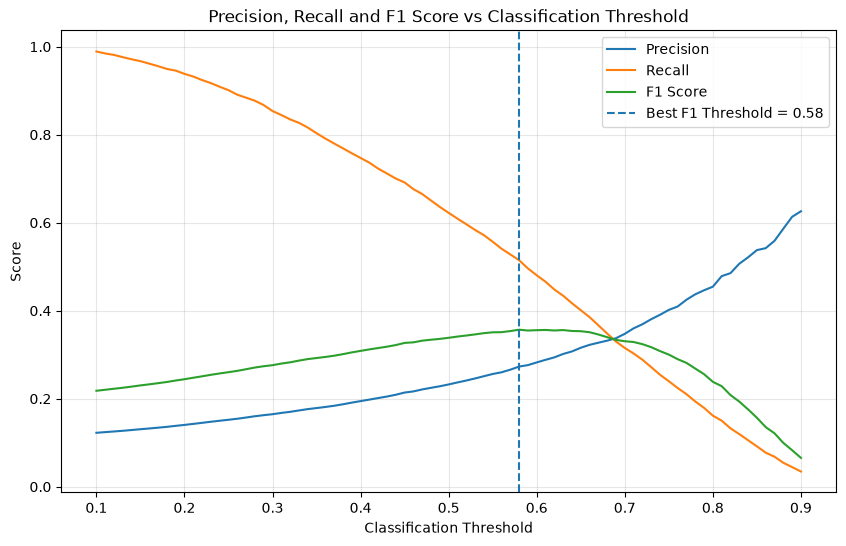

In [19]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1 Score"],
    label="F1 Score"
)

plt.axvline(
    best_f1_threshold,
    linestyle="--",
    label=f"Best F1 Threshold = {best_f1_threshold:.2f}"
)

plt.title("Precision, Recall and F1 Score vs Classification Threshold")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


In [20]:
threshold_results.sort_values(
    by="F1 Score",
    ascending=False
).head(10)

,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC
48,0.58,0.784511,0.273032,0.514755,0.356809,0.740867
51,0.61,0.804484,0.288361,0.465852,0.356222,0.740867
53,0.63,0.817628,0.301685,0.434022,0.355951,0.740867
50,0.60,0.797949,0.282439,0.480396,0.355732,0.740867
52,0.62,0.810921,0.293931,0.448145,0.355014,0.740867
49,0.59,0.790655,0.276336,0.495995,0.354929,0.740867
54,0.64,0.823233,0.307429,0.416948,0.353909,0.740867
47,0.57,0.776018,0.265959,0.527825,0.353697,0.740867
55,0.65,0.829548,0.315798,0.401138,0.353389,0.740867
46,0.56,0.767941,0.260006,0.540894,0.351194,0.740867


In [21]:
minimum_recall = 0.50

eligible_thresholds = threshold_results[
    threshold_results["Recall"] >= minimum_recall
].copy()

eligible_thresholds = eligible_thresholds.sort_values(
    by="Precision",
    ascending=False
)

eligible_thresholds.head(10)

,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC
48,0.58,0.784511,0.273032,0.514755,0.356809,0.740867
47,0.57,0.776018,0.265959,0.527825,0.353697,0.740867
46,0.56,0.767941,0.260006,0.540894,0.351194,0.740867
45,0.55,0.760843,0.256184,0.556703,0.350894,0.740867
44,0.54,0.752301,0.251111,0.571669,0.348945,0.740867
43,0.53,0.744028,0.246044,0.583474,0.346130,0.740867
42,0.52,0.735339,0.241282,0.596543,0.343593,0.740867
41,0.51,0.726846,0.236963,0.609191,0.341204,0.740867
40,0.50,0.717496,0.232404,0.622260,0.338416,0.740867
39,0.49,0.708170,0.228295,0.635750,0.335951,0.740867


### Business Threshold Candidate

Among the thresholds achieving at least 50% recall, the threshold with the
highest precision provides a useful business-oriented operating point.

The final threshold will be selected after comparing:

- F1-optimized threshold
- Recall-constrained threshold
- Overall business trade-offs

In [22]:
if len(eligible_thresholds) > 0:

    business_threshold = (
        eligible_thresholds.iloc[0]["Threshold"]
    )

    print(
        "Business Threshold:",
        round(business_threshold, 2)
    )

    print(
        "Precision:",
        round(
            eligible_thresholds.iloc[0]["Precision"],
            4
        )
    )

    print(
        "Recall:",
        round(
            eligible_thresholds.iloc[0]["Recall"],
            4
        )
    )

    print(
        "F1 Score:",
        round(
            eligible_thresholds.iloc[0]["F1 Score"],
            4
        )
    )

else:

    business_threshold = best_f1_threshold

    print(
        "No threshold achieved the minimum recall target."
    )

    print(
        "Using the best F1 threshold:",
        round(business_threshold, 2)
    )

Business Threshold: 0.58
Precision: 0.273
Recall: 0.5148
F1 Score: 0.3568


### XGBoost Hyperparameter Tuning

The class-weighted XGBoost model demonstrated a substantial improvement
in minority-class recall.

The next step is to optimize the model's hyperparameters to determine
whether its predictive performance can be further improved.

The following hyperparameters will be explored:

- Number of boosting trees
- Learning rate
- Maximum tree depth
- Minimum child weight
- Subsample ratio
- Column sampling ratio

RandomizedSearchCV with stratified cross-validation will be used to
efficiently explore the parameter space.

The validation and test datasets will remain separate from the tuning
process.

In [23]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100, 200, 300, 400],
    "learning_rate": [0.03, 0.05, 0.1, 0.15],
    "max_depth": [3, 4, 5, 6, 7],
    "min_child_weight": [1, 3, 5, 7],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

cv_strategy = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=15,
    scoring="f1",
    cv=cv_strategy,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_random_search.fit(
    X_model,
    y_model
)

print("Best Parameters:")
print(xgb_random_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(round(xgb_random_search.best_score_, 4))

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best Parameters:
{'subsample': 0.9, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 1.0}

Best Cross-Validation F1 Score:
0.3454


### Train Optimized XGBoost

The best hyperparameters identified through RandomizedSearchCV will now be
used to train the optimized XGBoost model.

The optimized model will be evaluated on the validation set before performing
the final evaluation on the untouched test set.

In [24]:
# Retrieve the best model from RandomizedSearchCV

optimized_xgb = xgb_random_search.best_estimator_

print("Optimized XGBoost trained successfully.")

print("\nBest Parameters:")
for parameter, value in xgb_random_search.best_params_.items():
    print(f"{parameter}: {value}")

Optimized XGBoost trained successfully.

Best Parameters:
subsample: 0.9
n_estimators: 300
min_child_weight: 1
max_depth: 7
learning_rate: 0.05
colsample_bytree: 1.0


### Evaluate optimized XGboost

In [25]:
# Generate validation predictions

optimized_val_prob = optimized_xgb.predict_proba(
    X_validation
)[:, 1]

optimized_val_pred = (
    optimized_val_prob >= 0.50
).astype(int)


# Calculate metrics

optimized_val_accuracy = accuracy_score(
    y_validation,
    optimized_val_pred
)

optimized_val_precision = precision_score(
    y_validation,
    optimized_val_pred,
    zero_division=0
)

optimized_val_recall = recall_score(
    y_validation,
    optimized_val_pred,
    zero_division=0
)

optimized_val_f1 = f1_score(
    y_validation,
    optimized_val_pred,
    zero_division=0
)

optimized_val_roc_auc = roc_auc_score(
    y_validation,
    optimized_val_prob
)


print("Optimized XGBoost — Validation Performance")
print("=" * 50)

print(f"Accuracy  : {optimized_val_accuracy:.4f}")
print(f"Precision : {optimized_val_precision:.4f}")
print(f"Recall    : {optimized_val_recall:.4f}")
print(f"F1 Score  : {optimized_val_f1:.4f}")
print(f"ROC-AUC   : {optimized_val_roc_auc:.4f}")

Optimized XGBoost — Validation Performance
Accuracy  : 0.7312
Precision : 0.2397
Recall    : 0.6054
F1 Score  : 0.3434
ROC-AUC   : 0.7401


### Threshold optimization for optimized XGboost

In [26]:
optimized_threshold_results = []

thresholds = np.arange(0.10, 0.91, 0.01)

for threshold in thresholds:

    predictions = (
        optimized_val_prob >= threshold
    ).astype(int)

    optimized_threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_validation,
            predictions
        ),
        "Precision": precision_score(
            y_validation,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_validation,
            predictions,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_validation,
            predictions,
            zero_division=0
        )
    })

optimized_threshold_results = pd.DataFrame(
    optimized_threshold_results
)

optimized_threshold_results.head()

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.10,0.185970,0.123647,0.987352,0.219772
1,0.11,0.199824,0.125080,0.982715,0.221915
2,0.12,0.216247,0.126823,0.977024,0.224504
3,0.13,0.231643,0.128485,0.971332,0.226950
4,0.14,0.248336,0.130661,0.968170,0.230249


## Threshold 1

In [27]:
best_optimized_threshold_row = (
    optimized_threshold_results.loc[
        optimized_threshold_results["F1 Score"].idxmax()
    ]
)

best_optimized_threshold = (
    best_optimized_threshold_row["Threshold"]
)

print("Best Threshold:", round(best_optimized_threshold, 2))

print(
    "Accuracy:",
    round(best_optimized_threshold_row["Accuracy"], 4)
)

print(
    "Precision:",
    round(best_optimized_threshold_row["Precision"], 4)
)

print(
    "Recall:",
    round(best_optimized_threshold_row["Recall"], 4)
)

print(
    "F1 Score:",
    round(best_optimized_threshold_row["F1 Score"], 4)
)

Best Threshold: 0.59
Accuracy: 0.8008
Precision: 0.2846
Recall: 0.4726
F1 Score: 0.3553


## Threshold 2

In [28]:
minimum_recall = 0.50

optimized_eligible_thresholds = (
    optimized_threshold_results[
        optimized_threshold_results["Recall"] >= minimum_recall
    ]
    .sort_values(
        by="Precision",
        ascending=False
    )
)

if not optimized_eligible_thresholds.empty:

    optimized_business_threshold = (
        optimized_eligible_thresholds.iloc[0]["Threshold"]
    )

    selected_row = optimized_eligible_thresholds.iloc[0]

    print(
        "Business Threshold:",
        round(optimized_business_threshold, 2)
    )

    print(
        "Precision:",
        round(selected_row["Precision"], 4)
    )

    print(
        "Recall:",
        round(selected_row["Recall"], 4)
    )

    print(
        "F1 Score:",
        round(selected_row["F1 Score"], 4)
    )

else:

    optimized_business_threshold = (
        best_optimized_threshold
    )

    print(
        "No threshold achieved 50% recall."
    )

    print(
        "Using best F1 threshold:",
        round(optimized_business_threshold, 2)
    )

Business Threshold: 0.57
Precision: 0.273
Recall: 0.5061
F1 Score: 0.3547


### Comparaing Both Threshold

In [30]:
threshold_comparison = pd.DataFrame({
    "Strategy": [
        "Best F1",
        "Business Recall >= 50%"
    ],
    "Threshold": [
        best_optimized_threshold,
        optimized_business_threshold
    ]
})

threshold_comparison

,Strategy,Threshold
0,Best F1,0.59
1,Business Recall >= 50%,0.57


## Plotting optimized Threshold

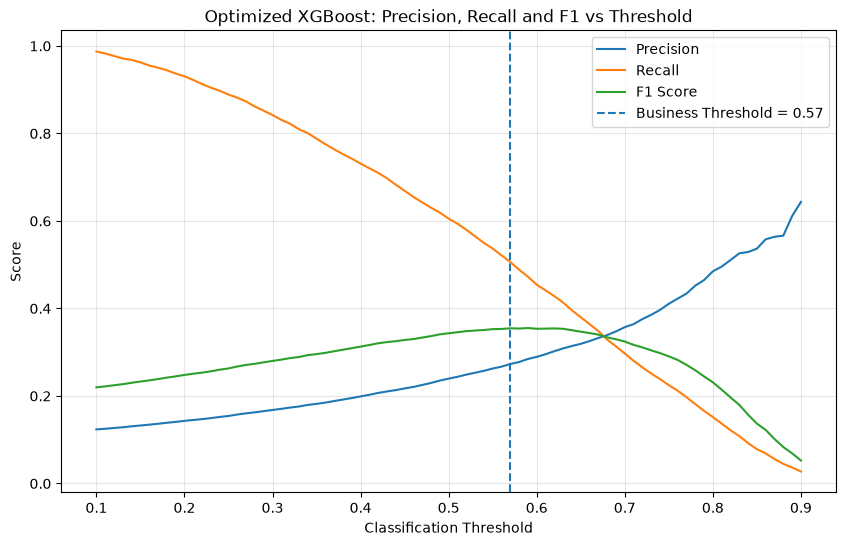

In [31]:
plt.figure(figsize=(10, 6))

plt.plot(
    optimized_threshold_results["Threshold"],
    optimized_threshold_results["Precision"],
    label="Precision"
)

plt.plot(
    optimized_threshold_results["Threshold"],
    optimized_threshold_results["Recall"],
    label="Recall"
)

plt.plot(
    optimized_threshold_results["Threshold"],
    optimized_threshold_results["F1 Score"],
    label="F1 Score"
)

plt.axvline(
    optimized_business_threshold,
    linestyle="--",
    label=f"Business Threshold = {optimized_business_threshold:.2f}"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title(
    "Optimized XGBoost: Precision, Recall and F1 vs Threshold"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Final Model Evaluation on the Test Set

The optimized XGBoost model is now evaluated on the previously untouched
test dataset.

The business-selected classification threshold of 0.57 is applied to the
predicted default probabilities.

This test set is used only for final performance estimation and has not
been used during model or threshold optimization.

In [32]:
# Final probability predictions

final_test_prob = optimized_xgb.predict_proba(
    X_test
)[:, 1]

# Apply selected business threshold

final_threshold = optimized_business_threshold

final_test_pred = (
    final_test_prob >= final_threshold
).astype(int)

print("Final Threshold:", round(final_threshold, 2))

Final Threshold: 0.57


In [34]:
final_accuracy = accuracy_score(
    y_test,
    final_test_pred
)

final_precision = precision_score(
    y_test,
    final_test_pred,
    zero_division=0
)

final_recall = recall_score(
    y_test,
    final_test_pred,
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    final_test_pred,
    zero_division=0
)

final_roc_auc = roc_auc_score(
    y_test,
    final_test_prob
)

print("FINAL MODEL PERFORMANCE")
print("=" * 50)

print(f"Accuracy  : {final_accuracy:.4f}")
print(f"Precision : {final_precision:.4f}")
print(f"Recall    : {final_recall:.4f}")
print(f"F1 Score  : {final_f1:.4f}")
print(f"ROC-AUC   : {final_roc_auc:.4f}")

FINAL MODEL PERFORMANCE
Accuracy  : 0.7873
Precision : 0.2794
Recall    : 0.5267
F1 Score  : 0.3651
ROC-AUC   : 0.7519


Confusion Matrix:
[[37082  8057]
 [ 2807  3124]]


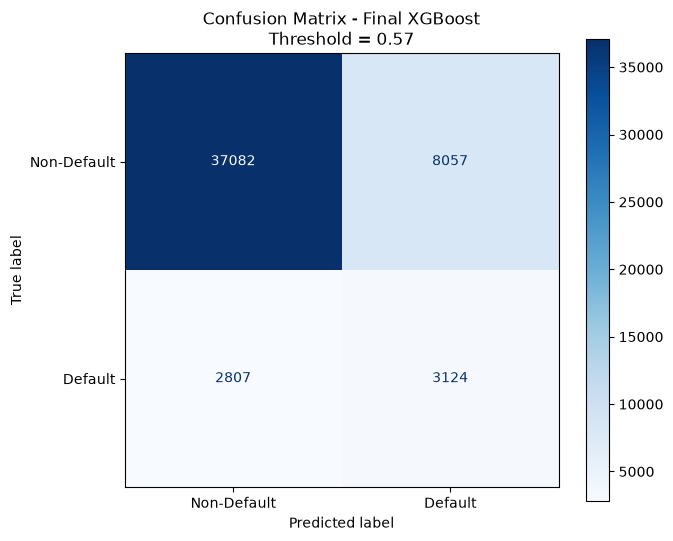

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    final_test_pred
)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Default", "Default"]
)

fig, ax = plt.subplots(figsize=(7, 6))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

plt.title(
    f"Confusion Matrix - Final XGBoost\nThreshold = {final_threshold:.2f}"
)

plt.show()

In [36]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        final_test_pred,
        target_names=["Non-Default", "Default"],
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

 Non-Default     0.9296    0.8215    0.8722     45139
     Default     0.2794    0.5267    0.3651      5931

    accuracy                         0.7873     51070
   macro avg     0.6045    0.6741    0.6187     51070
weighted avg     0.8541    0.7873    0.8133     51070



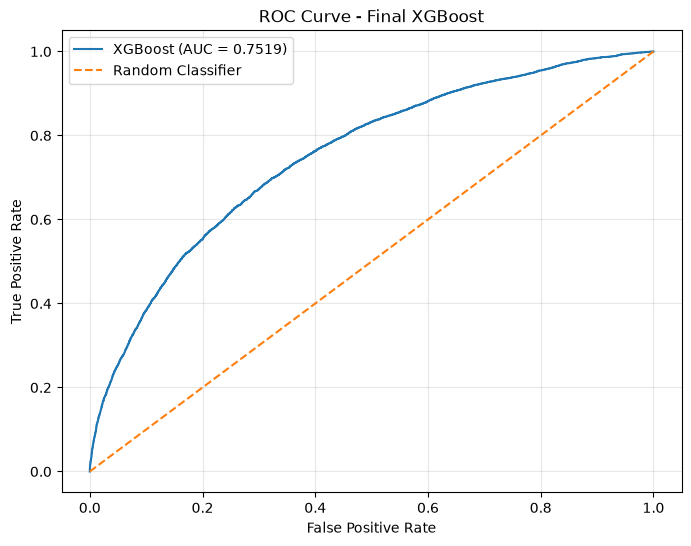

In [37]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds_roc = roc_curve(
    y_test,
    final_test_prob
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final XGBoost")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

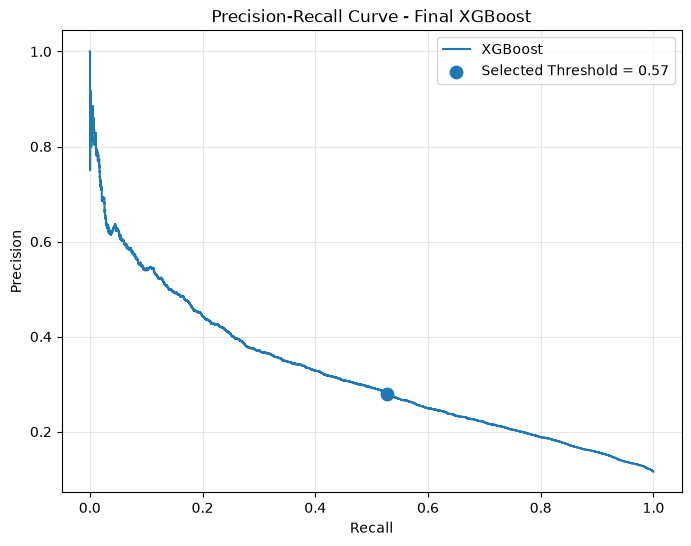

In [38]:
from sklearn.metrics import precision_recall_curve

precision_values, recall_values, pr_thresholds = (
    precision_recall_curve(
        y_test,
        final_test_prob
    )
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_values,
    precision_values,
    label="XGBoost"
)

plt.scatter(
    final_recall,
    final_precision,
    s=80,
    label=f"Selected Threshold = {final_threshold:.2f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curve - Final XGBoost"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Final Model Summary

After class-imbalance handling, hyperparameter tuning, probability
threshold optimization, and evaluation on the untouched test set,
the final XGBoost model is selected for deployment.

The model uses a business-oriented threshold designed to maintain a
minimum recall of 50% for default detection.

In [39]:
final_summary = pd.DataFrame({
    "Metric": [
        "Model",
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Value": [
        "Optimized XGBoost",
        round(final_threshold, 2),
        round(final_accuracy, 4),
        round(final_precision, 4),
        round(final_recall, 4),
        round(final_f1, 4),
        round(final_roc_auc, 4)
    ]
})

final_summary

,Metric,Value
0,Model,Optimized XGBoost
1,Threshold,0.57
2,Accuracy,0.7873
3,Precision,0.2794
4,Recall,0.5267
5,F1 Score,0.3651
6,ROC-AUC,0.7519


## Business Interpretation

The final XGBoost model is designed to prioritize the detection of
potential loan defaults rather than maximizing overall accuracy.

The model achieved a recall of approximately 52.67% on the unseen test
set, meaning that it successfully identified more than half of the
actual default cases.

A classification threshold of 0.57 was selected based on validation
data because it satisfied the project's minimum recall requirement of
50% while maintaining a reasonable balance between precision and recall.

The ROC-AUC of approximately 0.75 indicates that the model has useful
discriminative ability between default and non-default applicants.

Because false negatives can represent financially risky lending
decisions, recall is treated as an important business metric alongside
precision and F1-score.

### Save Final Model Artifacts

The final optimized XGBoost model and its selected classification
threshold are saved for later integration with the reusable prediction
pipeline and Streamlit application.

In [40]:
import os
import joblib

# Create models directory
os.makedirs("../models", exist_ok=True)

# Save final XGBoost model
joblib.dump(
    optimized_xgb,
    "../models/xgboost_model.pkl"
)

# Save final classification threshold
joblib.dump(
    final_threshold,
    "../models/threshold.pkl"
)

print("Final model artifacts saved successfully.")

Final model artifacts saved successfully.


### Saving Threshold Model

In [41]:
import joblib

# Check the saved threshold
saved_threshold = joblib.load("../models/threshold.pkl")

print("Saved Threshold:", saved_threshold)

# Check the saved model types
model_1 = joblib.load("../models/final_model.pkl")
model_2 = joblib.load("../models/xgboost_model.pkl")

print("\nfinal_model.pkl:")
print(type(model_1))

print("\nxgboost_model.pkl:")
print(type(model_2))

Saved Threshold: 0.5699999999999997

final_model.pkl:
<class 'xgboost.sklearn.XGBClassifier'>

xgboost_model.pkl:
<class 'xgboost.sklearn.XGBClassifier'>
